<a href="https://colab.research.google.com/github/kareenadwight/MAT3373-Machine-Learning-Notes/blob/main/MAT3373_Short_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Part 1: School A

We can solve this using a linear regression model

$$Y_i = \beta_0 + \beta_1 X_i + \epsilon_i,$$

where $X_i$ is IQ and $Y_i$ is diligence.

We will test

$$H_0: \beta_1 = 0$$

vs

$$H_A: \beta_1 \neq 0.$$

The null hypothesis represents no linear relationship between IQ and diligence.
The alternative represents a linear relationship.

Slope: -0.5545756007361781
Intercept: 173.42780332359112
P-value: 0.0


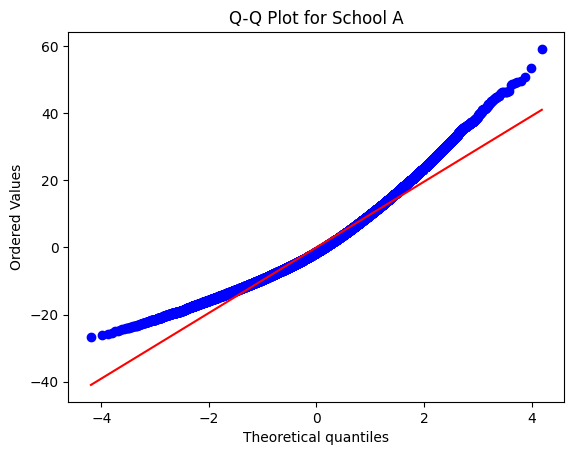

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Read the School A data
schoolA = pd.read_csv("SchoolA.csv")

# X is IQ and Y is diligence
x = schoolA.iloc[:, 0]
y = schoolA.iloc[:, 1]

# Linear regression
regression = stats.linregress(x, y)

print("Slope:", regression.slope)
print("Intercept:", regression.intercept)
print("P-value:", regression.pvalue)

# Find the residuals
predicted_y = regression.intercept + regression.slope * x
residuals = y - predicted_y

# Make a Q-Q plot
stats.probplot(residuals, plot=plt)
plt.title("Q-Q Plot for School A")
plt.show()

The estimated slope is $\hat{\beta}_1=-0.555$. The p-value is approximately 0, which is less than 0.05, so we reject $H_0$. There is evidence of a negative relationship between IQ and diligence for School A.
The points on the Q-Q plot do not closely follow the straight line, so the residuals do not appear to be approximately Gaussian.

## Part 2: Schools B, C

Repeating the same analysis for Schools B and C.

Slope: -0.8901017383126405
Intercept: 189.05629020486538
P-value: 0.0


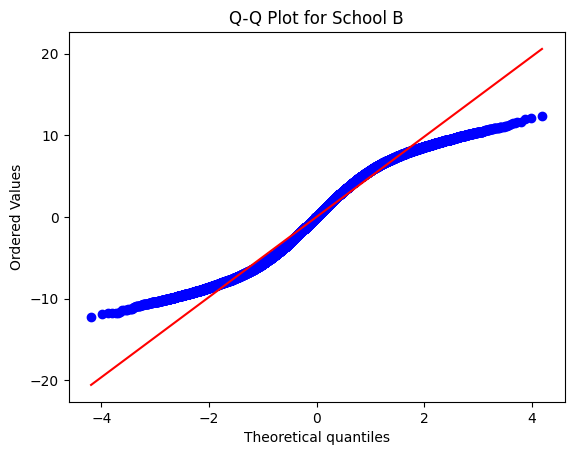

In [14]:
# Read School B
schoolB = pd.read_csv("SchoolB.csv")

# Choose X and Y
xB = schoolB.iloc[:, 0]
yB = schoolB.iloc[:, 1]

# Do the regression
regressionB = stats.linregress(xB, yB)

print("Slope:", regressionB.slope)
print("Intercept:", regressionB.intercept)
print("P-value:", regressionB.pvalue)

# Calculate residuals
predictedB = regressionB.intercept + regressionB.slope * xB
residualsB = yB - predictedB

# Q-Q plot
stats.probplot(residualsB, plot=plt)
plt.title("Q-Q Plot for School B")
plt.show()

Slope: -0.5617109779711297
Intercept: 138.22679862140907
P-value: 0.0


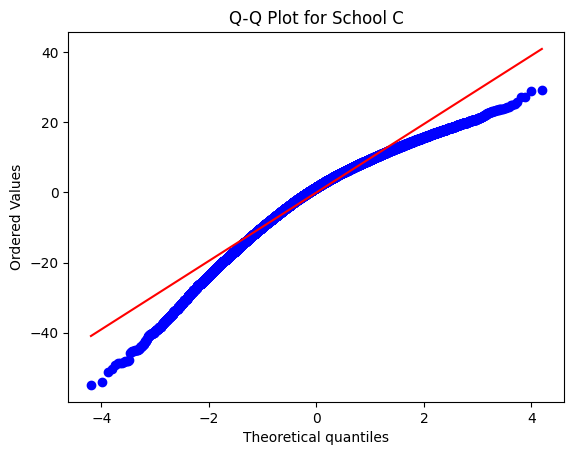

In [15]:
# Read School C
schoolC = pd.read_csv("SchoolC.csv")

# Choose X and Y
xC = schoolC.iloc[:, 0]
yC = schoolC.iloc[:, 1]

# Do the regression
regressionC = stats.linregress(xC, yC)

print("Slope:", regressionC.slope)
print("Intercept:", regressionC.intercept)
print("P-value:", regressionC.pvalue)

# Calculate residuals
predictedC = regressionC.intercept + regressionC.slope * xC
residualsC = yC - predictedC

# Q-Q plot
stats.probplot(residualsC, plot=plt)
plt.title("Q-Q Plot for School C")
plt.show()

For School B, the estimated slope is $\hat{\beta}_1=-0.890$ and the p-value is approximately 0. For School C, the estimated slope is $\hat{\beta}_1=-0.562$ and the p-value is also approximately 0. Therefore, we reject $H_0$ for both schools.

The Q-Q plots for Schools B and C do not closely follow the straight line, so the residuals do not appear to be approximately Gaussian.

All three schools give roughly the same answer. The estimated slopes for Schools A, B, and C all have a negative relationship between IQ and diligence within each school.

## Part 3

### 1. Theory

For a linear regression with known residual variance $\sigma^2$, the variance of the estimated slope is

$$
\operatorname{Var}(\hat{\beta}_1)
=
\frac{\sigma^2}{\sum_i (X_i-\bar X)^2}.
$$

When independent datasets are combined, the total variation in the $X$ values cannot decrease. Therefore,

$$
\sum_{\text{combined}}(X_i-\bar X)^2
\geq
\sum_{\text{one dataset}}(X_i-\bar X)^2.
$$

Since $\sigma^2$ is the same, the variance and standard error of $\hat{\beta}_1$ cannot increase when the datasets are combined. Therefore, the confidence interval for $\beta_1$ becomes smaller.

Slope: 0.0006607278257434565
Intercept: 99.94581809709763
P-value: 0.7978868742393432


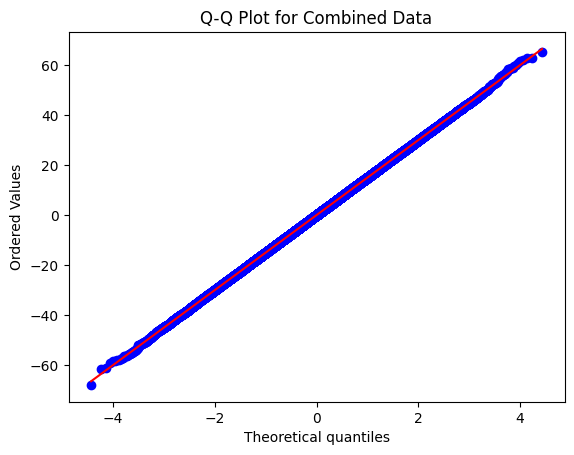

In [16]:
# Combine
combined = pd.concat([schoolA, schoolB, schoolC])

# Choose X and Y
xCombined = combined.iloc[:, 0]
yCombined = combined.iloc[:, 1]

# Do the regression
regressionCombined = stats.linregress(xCombined, yCombined)

print("Slope:", regressionCombined.slope)
print("Intercept:", regressionCombined.intercept)
print("P-value:", regressionCombined.pvalue)

# Calculate residuals
predictedCombined = regressionCombined.intercept + regressionCombined.slope * xCombined
residualsCombined = yCombined - predictedCombined

# Q-Q plot
stats.probplot(residualsCombined, plot=plt)
plt.title("Q-Q Plot for Combined Data")
plt.show()

Students with higher IQ trend to have higher diligence. The three schools contain different groups of students.

When the three schools are combined, these differences between the schools hide the relationship that can be seen within each individual school. Therefore, looking at all students together gives a different impression than looking at students within the same school.